In [65]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

## Exploratory Data Analysis

The goal is to demonstrate that it's reasonable to investigate how sensitive MADDPG is to hyperparameters (and environment parameters). That is, under what conditions does it fail to learn swarm behavior?

Some plots we can use are:
- histogram of average rewards
- box plot of rewards and/or DoS/DoA
- scatter plot of average reward, DoS, DoA

A really easy argument to make is: we see good learning behavior in one random seed, but not another.

We can also hypothesize when it may break depending on the "weaknesses" of MADDPG.

Experiments were done with:
```
{
    "dynamics_mode": "Polar",
    "n_p": 3,
    "n_e": 25,
    "pursuer_strategy": "input",
    "escaper_strategy": "input",
    "is_periodic": true,
    "render_traj": true,
    "save_frame": false,

    "m_p": 3.0,
    "m_e": 1.0,
    "size_p": 0.06,
    "size_e": 0.035
}
seed: 42, 43, 44, 500
episodes: 201
episode_length: 200
```

In [66]:
def load_data(file_path, print_info=True):
    data = pl.read_csv(file_path)
    if print_info:
        print(data.glimpse())
    return data


def plot_dos_and_doa(data: pl.DataFrame,
    axes=None, color='blue', window_size=10, show=True):
    """
    Plot DoS and DoA metrics with moving average and standard deviation bands.
    
    Args:
        data: Polars DataFrame containing the metrics
        ax: Axes object to plot on (if None, creates new figure)
        window_size: Window size for moving average calculation
    """
    if axes is None:
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        axes = axes.flatten()
    
    # Get the episode and metric columns
    episode = data['# episode'].to_numpy()
    
    # Plot DoS
    if 'dos' in data.columns:
        dos = data['dos'].to_numpy()
        dos_ma = np.convolve(dos, np.ones(window_size)/window_size, mode='valid')
        dos_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        dos_std = np.array([dos[max(0, i-window_size):i].std() for i in range(window_size, len(dos)+1)])
        
        axes[0].plot(dos_episodes, dos_ma, color=color, linewidth=2, label='Moving Average')
        axes[0].fill_between(dos_episodes, dos_ma - dos_std, dos_ma + dos_std, 
                            alpha=0.3, color=color, label='±1 Std Dev')
        axes[0].scatter(episode, dos, alpha=0.2, s=10, color='gray', label='Raw Data')
        axes[0].set_xlabel('Episode')
        axes[0].set_ylabel('DoS')
        # axes[0].set_title('Degree of Swarming (DoS)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # Plot DoA
    if 'doa' in data.columns:
        doa = data['doa'].to_numpy()
        doa_ma = np.convolve(doa, np.ones(window_size)/window_size, mode='valid')
        doa_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        doa_std = np.array([doa[max(0, i-window_size):i].std() for i in range(window_size, len(doa)+1)])
        
        axes[1].plot(doa_episodes, doa_ma, color=color, linewidth=2, label='Moving Average')
        axes[1].fill_between(doa_episodes, doa_ma - doa_std, doa_ma + doa_std, 
                            alpha=0.3, color=color, label='±1 Std Dev')
        axes[1].scatter(episode, doa, alpha=0.2, s=10, color='gray', label='Raw Data')
        axes[1].set_xlabel('Episode')
        axes[1].set_ylabel('DoA')
        # axes[1].set_title('Degree of Alignment (DoA)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if show:
        plt.show()


def compare_algorithms(data_maddpg: pl.DataFrame, data_ddpg: pl.DataFrame, metric: str, window_size=10):
    """
    Compare two algorithms (MADDPG and DDPG) for a specified metric with moving average and standard deviation bands.
    
    Args:
        data_maddpg: Polars DataFrame containing MADDPG results
        data_ddpg: Polars DataFrame containing DDPG results
        metric: Name of the metric to compare (e.g., 'dos' or 'doa')
        window_size: Window size for moving average calculation
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot DDPG
    if metric in data_ddpg.columns:
        episode_ddpg = data_ddpg['# episode'].to_numpy()
        metric_ddpg = data_ddpg[metric].to_numpy()
        metric_ma_ddpg = np.convolve(metric_ddpg, np.ones(
            window_size)/window_size, mode='valid')
        metric_episodes_ddpg = episode_ddpg[window_size-1:]

        # Calculate rolling standard deviation
        metric_std_ddpg = np.array([metric_ddpg[max(
            0, i-window_size):i].std() for i in range(window_size, len(metric_ddpg)+1)])

        ax.plot(metric_episodes_ddpg, metric_ma_ddpg, 'g-',
                linewidth=2, label='DDPG Moving Average')
        ax.fill_between(metric_episodes_ddpg, metric_ma_ddpg - metric_std_ddpg,
                        metric_ma_ddpg + metric_std_ddpg, alpha=0.3, color='green', label='DDPG ±1 Std Dev')
        ax.scatter(episode_ddpg, metric_ddpg, alpha=0.2,
                   s=10, color='gray', label='DDPG Raw Data')

    # Plot MADDPG
    if metric in data_maddpg.columns:
        episode_maddpg = data_maddpg['# episode'].to_numpy()
        metric_maddpg = data_maddpg[metric].to_numpy()
        metric_ma_maddpg = np.convolve(metric_maddpg, np.ones(window_size)/window_size, mode='valid')
        metric_episodes_maddpg = episode_maddpg[window_size-1:]
        
        # Calculate rolling standard deviation
        metric_std_maddpg = np.array([metric_maddpg[max(0, i-window_size):i].std() for i in range(window_size, len(metric_maddpg)+1)])
        
        ax.plot(metric_episodes_maddpg, metric_ma_maddpg, 'b-', linewidth=2, label='MADDPG Moving Average')
        ax.fill_between(metric_episodes_maddpg, metric_ma_maddpg - metric_std_maddpg, 
                        metric_ma_maddpg + metric_std_maddpg, alpha=0.3, color='blue', label='MADDPG ±1 Std Dev')
        ax.scatter(episode_maddpg, metric_maddpg, alpha=0.2, s=10, color='gray', label='MADDPG Raw Data')
    
    ax.set_xlabel('Episode')
    ax.set_ylabel(metric)
    ax.set_title(f'Comparison of {metric} between MADDPG and DDPG')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_rewards(data: pl.DataFrame, num_of_prey=3, window_size=10):
    """
    Plot rewards for each agent with moving average and standard deviation bands.
    
    Args:
        data: Polars DataFrame containing the rewards
        num_of_prey: Number of prey agents in the environment
        window_size: Window size for moving average calculation
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    episode = data['# episode'].to_numpy()
    reward_columns = [col for col in data.columns if col.startswith('reward_')]
    
    # plot prey (first num_of_prey reward columns)
    for i, reward_col in enumerate(reward_columns[:num_of_prey]):
        rewards = data[reward_col].to_numpy()
        rewards_ma = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
        reward_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        rewards_std = np.array([rewards[max(0, i-window_size):i].std() for i in range(window_size, len(rewards)+1)])
        
        ax.plot(reward_episodes, rewards_ma, linewidth=2, label=f'Prey {i+1}')
        ax.fill_between(reward_episodes, rewards_ma - rewards_std, rewards_ma + rewards_std, 
                        alpha=0.3)
        ax.scatter(episode, rewards, alpha=0.2, s=10, color='gray')

    # plot predator (last reward column)
    if len(reward_columns) > num_of_prey:
        predator_rewards = data[reward_columns[-1]].to_numpy()
        predator_rewards_ma = np.convolve(predator_rewards, np.ones(window_size)/window_size, mode='valid')
        predator_reward_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        predator_rewards_std = np.array([predator_rewards[max(0, i-window_size):i].std() for i in range(window_size, len(predator_rewards)+1)])
        
        ax.plot(predator_reward_episodes, predator_rewards_ma, 'r-', linewidth=2, label='Predators')
        ax.fill_between(predator_reward_episodes, predator_rewards_ma - predator_rewards_std, 
                        predator_rewards_ma + predator_rewards_std, alpha=0.3, color='red')
        ax.scatter(episode, predator_rewards, alpha=0.2, s=10, color='gray')
    
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.set_title('Agent Rewards Over Episodes')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_histogram(data: pl.DataFrame, column_name: str):
    """
    Plot a histogram of a specified column from the DataFrame.
    
    Args:
        data: Polars DataFrame containing the data
        column_name: Name of the column to plot
    """
    if column_name in data.columns:
        values = data[column_name].to_numpy()
        plt.figure(figsize=(10, 6))
        plt.hist(values, bins=30, alpha=0.7, color='blue')
        plt.xlabel(column_name)
        plt.ylabel('Frequency')
        plt.title(f'Histogram of {column_name}')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print(f"Column '{column_name}' not found in the DataFrame.")

## IDDPG vs MADDPG
Conclusion: the implementation of IDDPG is identical to MADDPG, and there is no observable difference between the two.
This is likely a result of a bad implementation, because in IDDPG, conspecifics still share the same actor and critic networks. That is, if you print the number of agents in the constructor, you get 2. Even though there is more than one prey and predators.

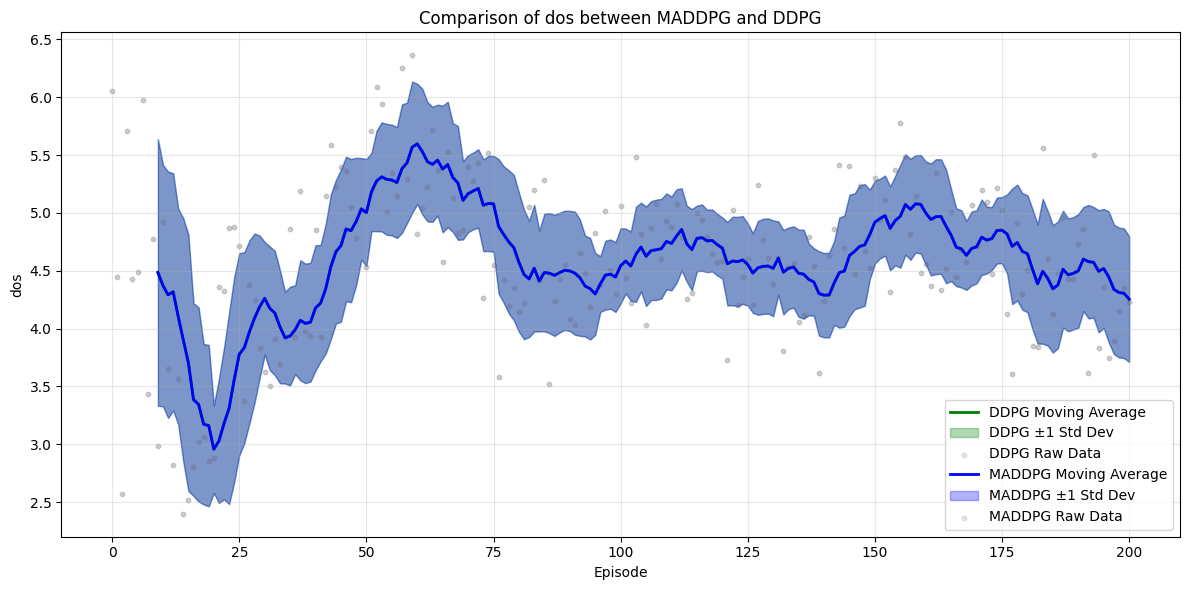

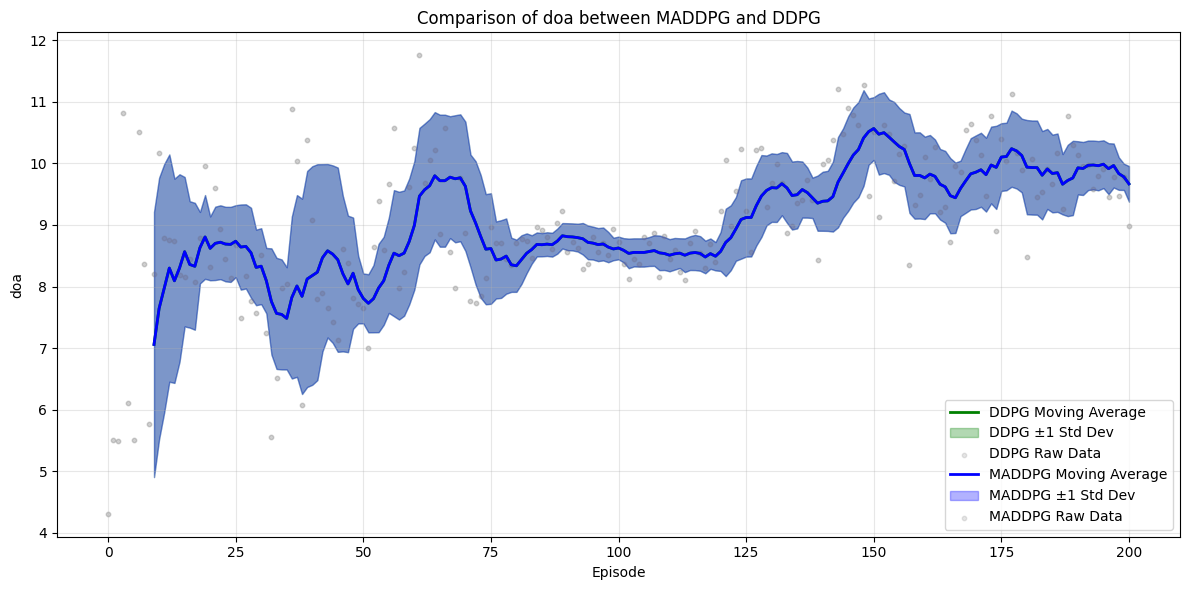

In [67]:
iddpg_file_path = '../experimental_methods/models/ddpg/run1/metrics.csv'
maddpg_file_path = '../experimental_methods/models/maddpg/run1/metrics.csv'

ddpg_data = load_data(iddpg_file_path, print_info=False)
maddpg_data = load_data(maddpg_file_path, print_info=False)
compare_algorithms(maddpg_data, ddpg_data, metric='dos', window_size=10)
compare_algorithms(maddpg_data, ddpg_data, metric='doa', window_size=10)

## MADDPG
There are subtle differences between each run, but they are very minor. Ideally, we would remove the curves and just make a scatter plot to visualize these trends.

The histogram indicates the rewards are following something like a poisson distribution.


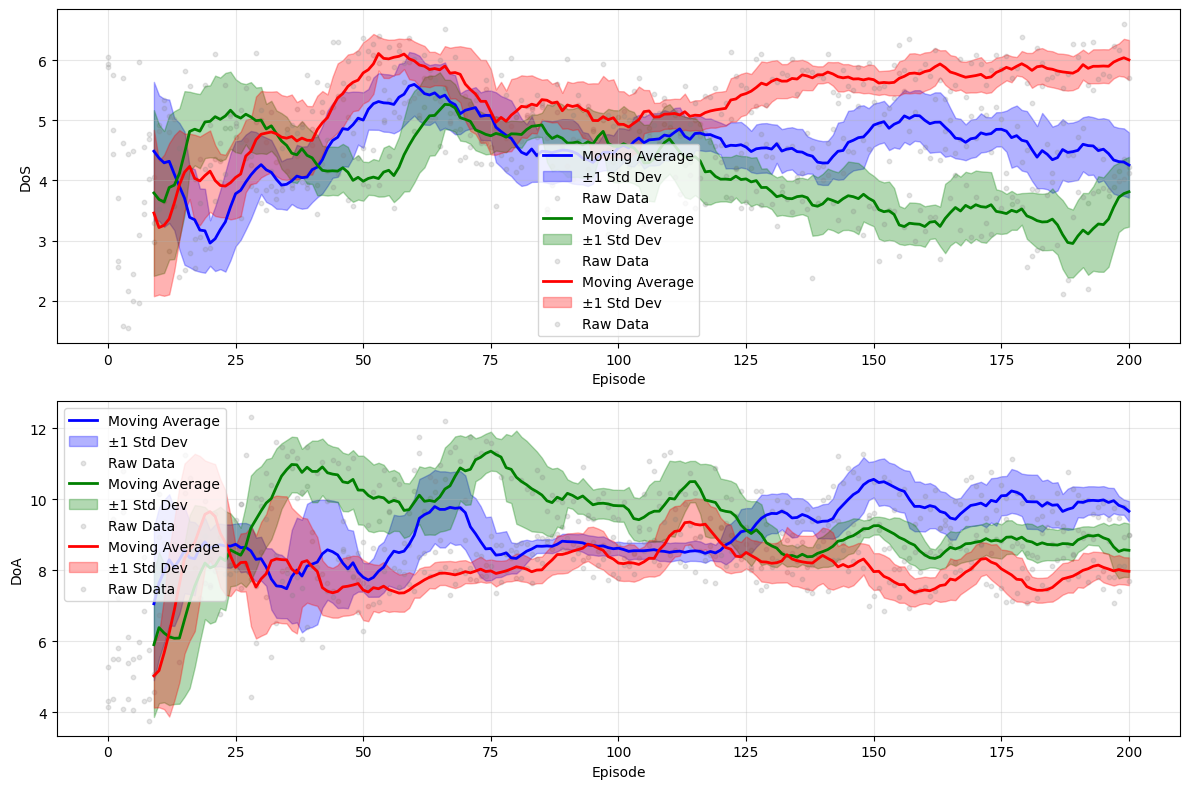

In [68]:
run1 = '../experimental_methods/models/maddpg/run1/metrics.csv'
run2 = '../experimental_methods/models/maddpg/run2/metrics.csv'
run3 = '../experimental_methods/models/maddpg/run3/metrics.csv'

maddpg_data1 = load_data(run1, print_info=False)
maddpg_data2 = load_data(run2, print_info=False)
maddpg_data3 = load_data(run3, print_info=False)

# plot DoS and DoA for multiple runs in one figure
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_dos_and_doa(maddpg_data1, window_size=10, axes=axes, color='blue', show=False)
plot_dos_and_doa(maddpg_data2, window_size=10, axes=axes, color='green', show=False)
plot_dos_and_doa(maddpg_data3, window_size=10, axes=axes, color='red', show=True)

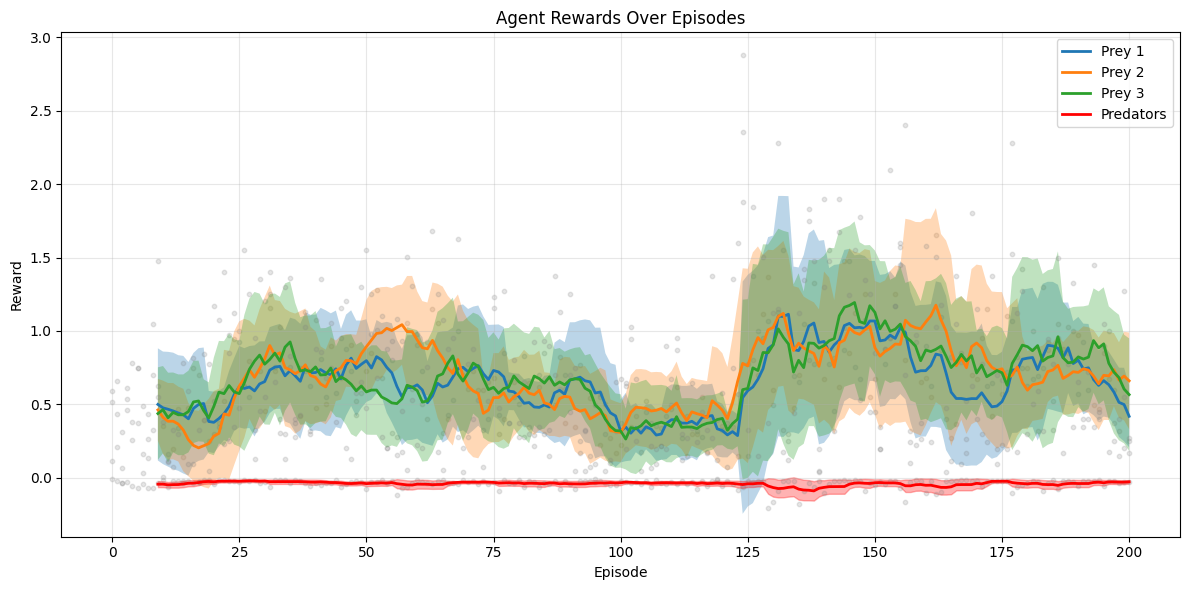

In [69]:
# plotting rewards for each agent in MADDPG run1
plot_rewards(maddpg_data1, window_size=10)

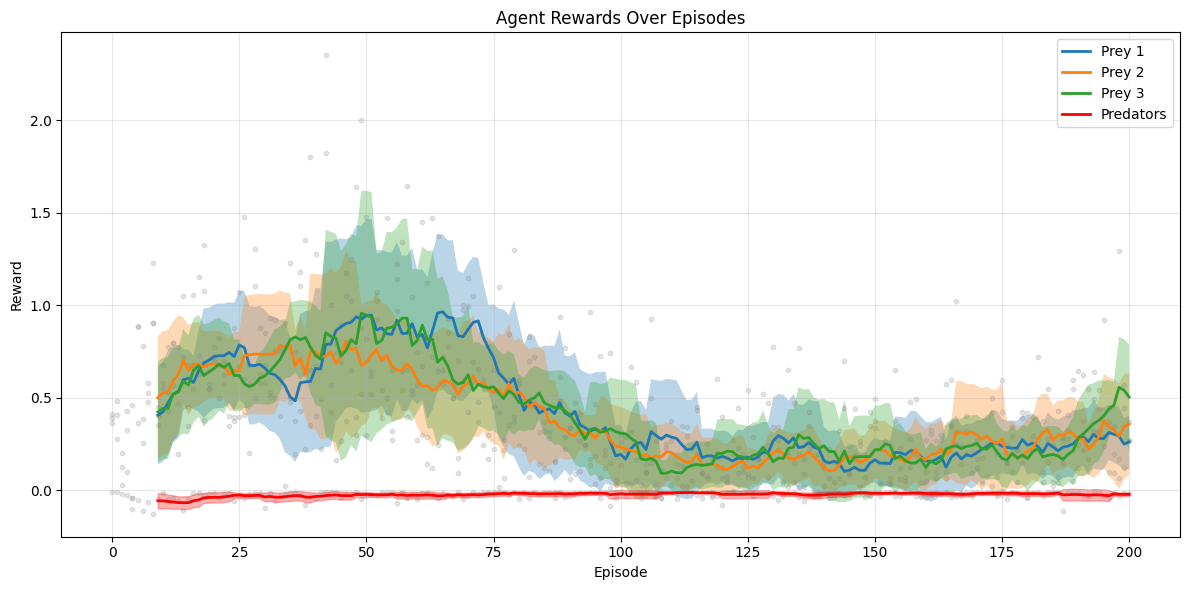

In [70]:
plot_rewards(maddpg_data2, num_of_prey=3, window_size=10)

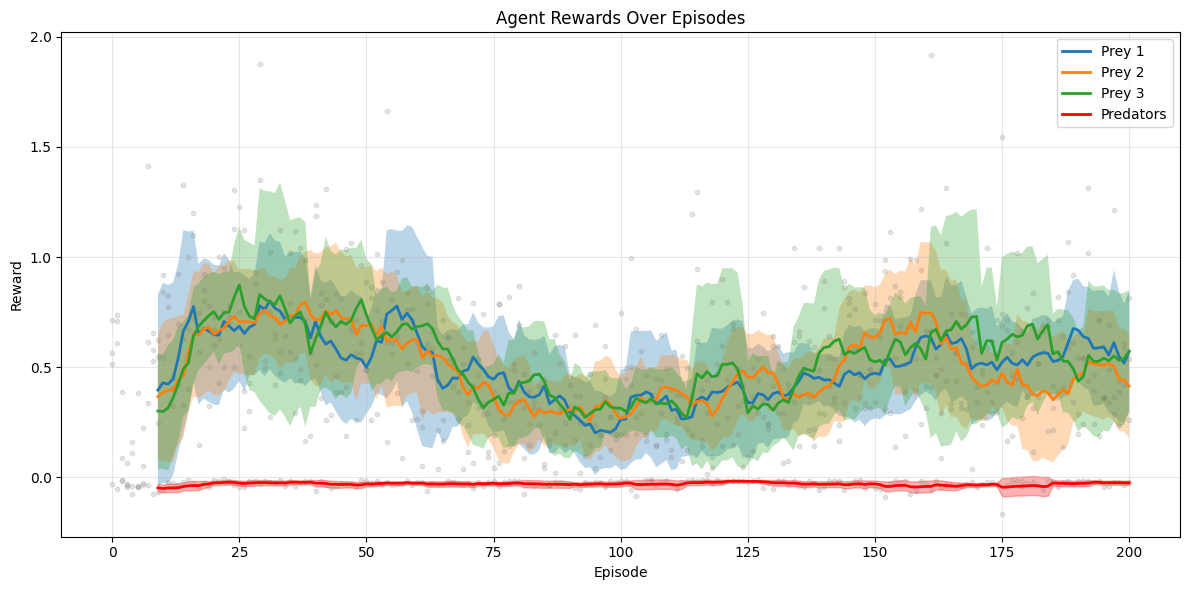

In [71]:
plot_rewards(maddpg_data3, num_of_prey=3, window_size=10)

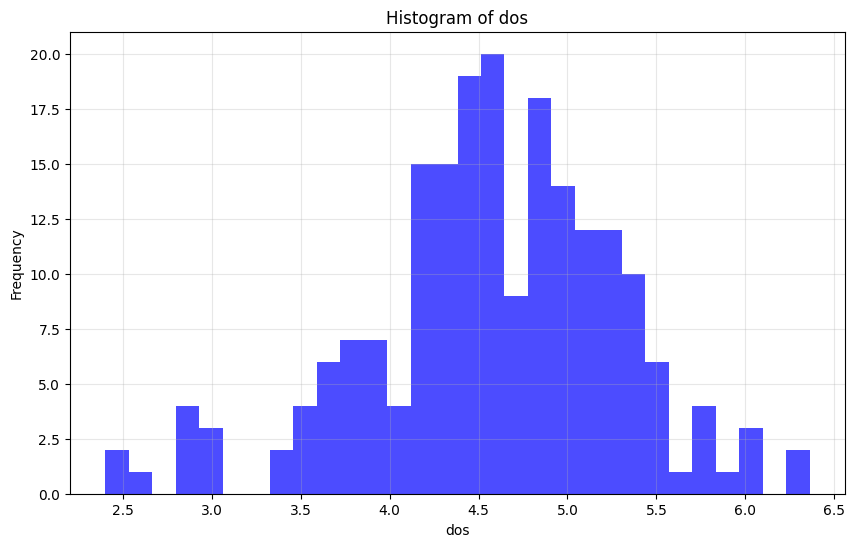

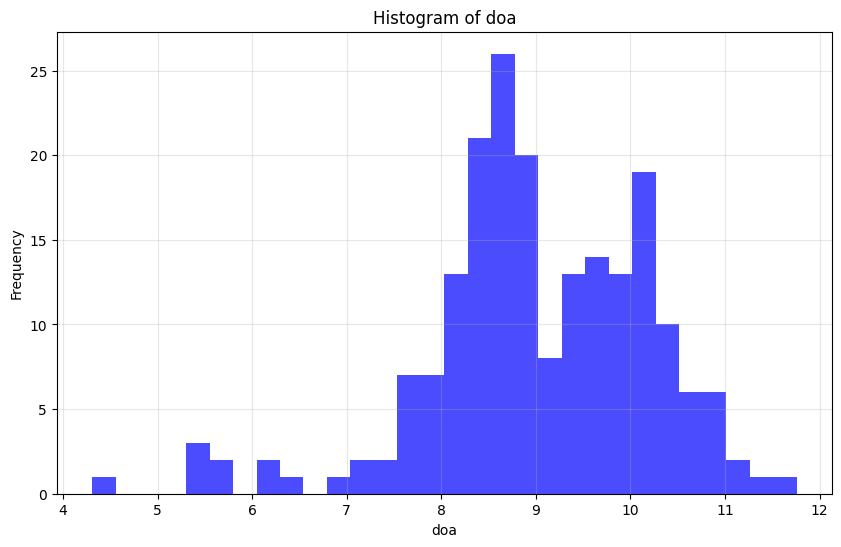

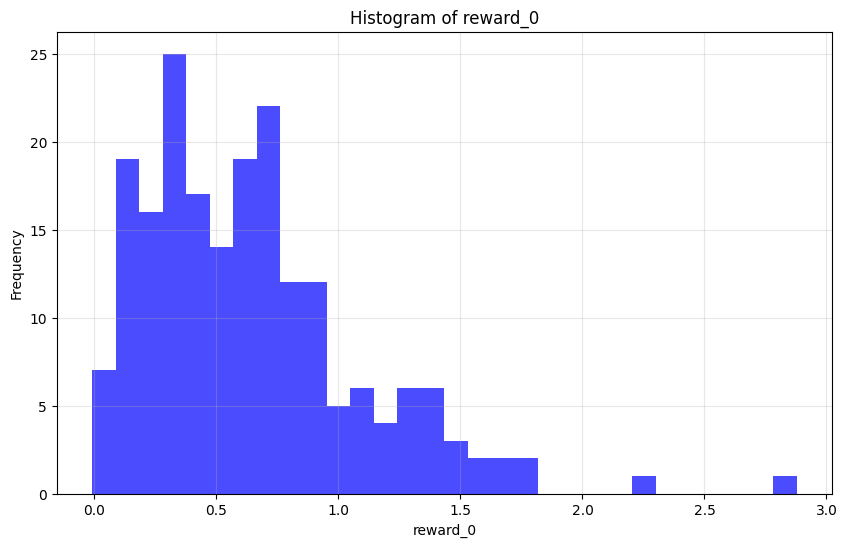

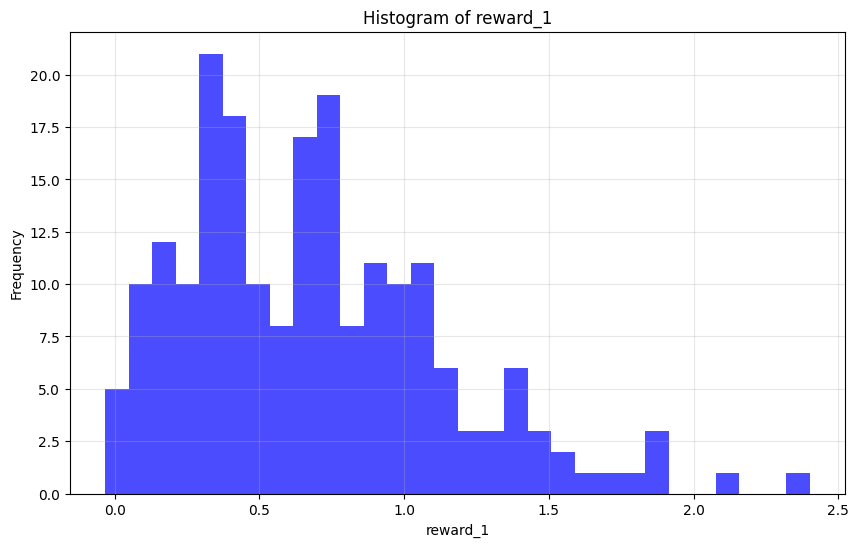

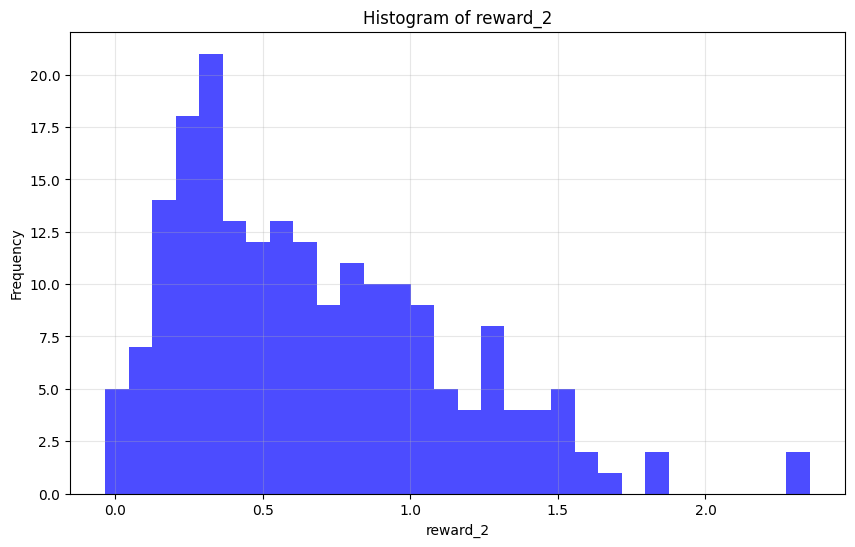

In [74]:
plot_histogram(maddpg_data1, column_name='dos')
plot_histogram(maddpg_data1, column_name='doa')
plot_histogram(maddpg_data1, column_name='reward_0')
plot_histogram(maddpg_data1, column_name='reward_1')
plot_histogram(maddpg_data1, column_name='reward_2')

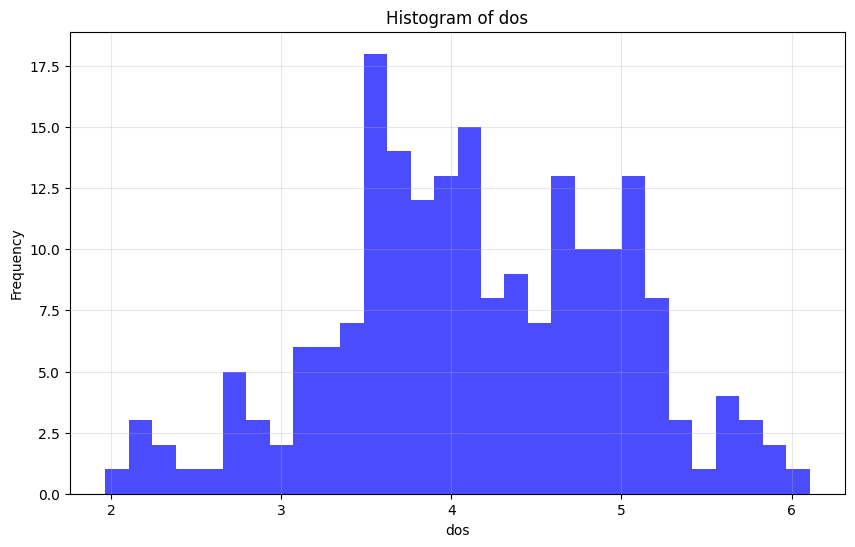

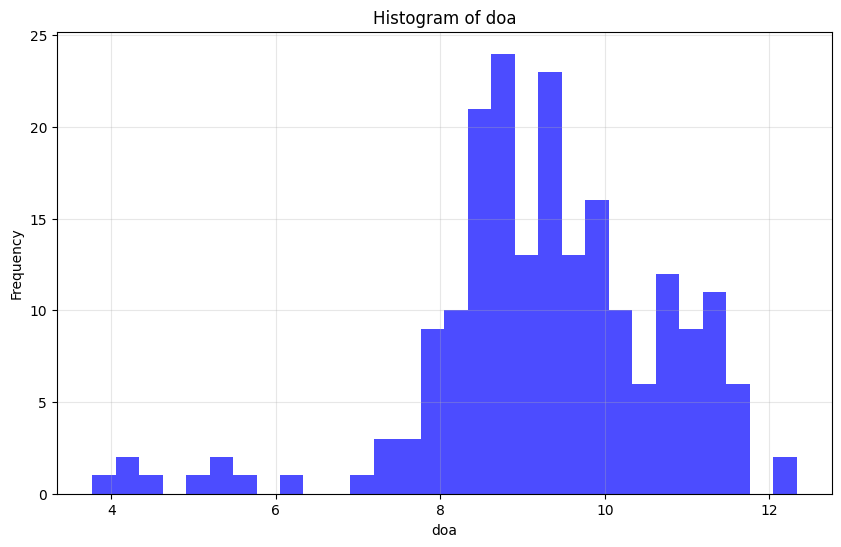

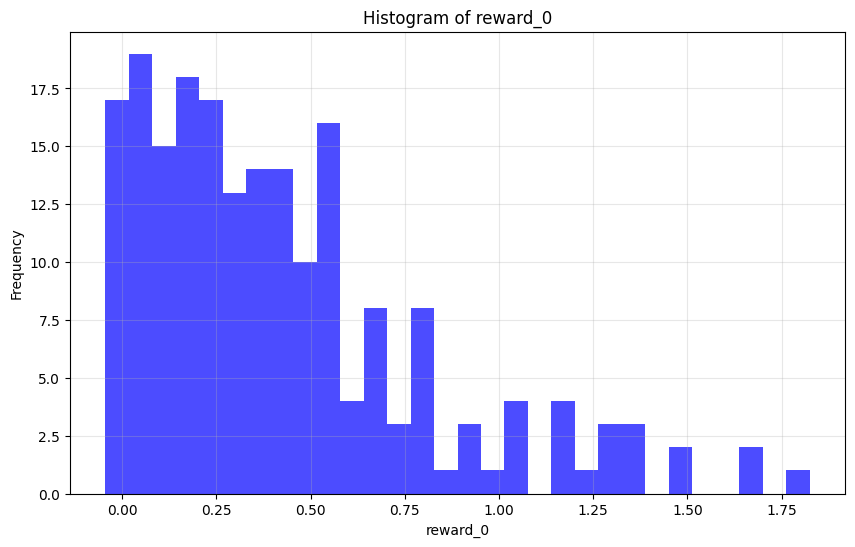

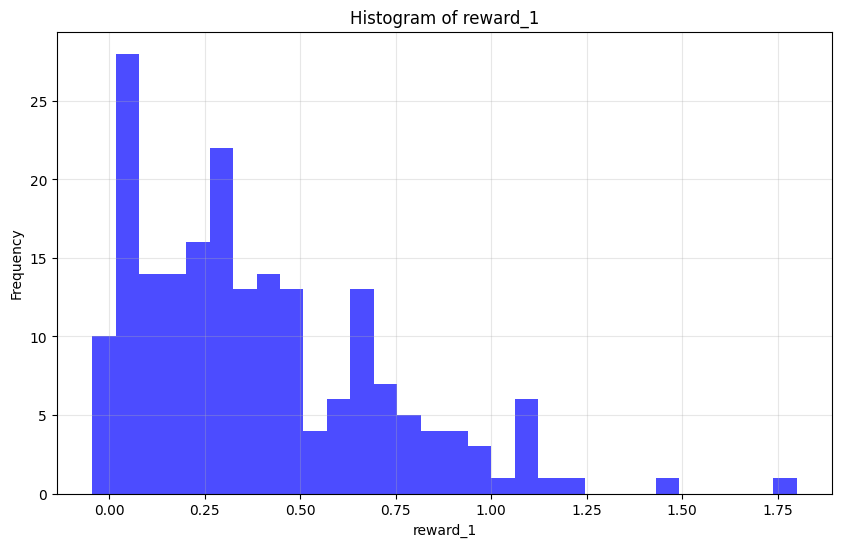

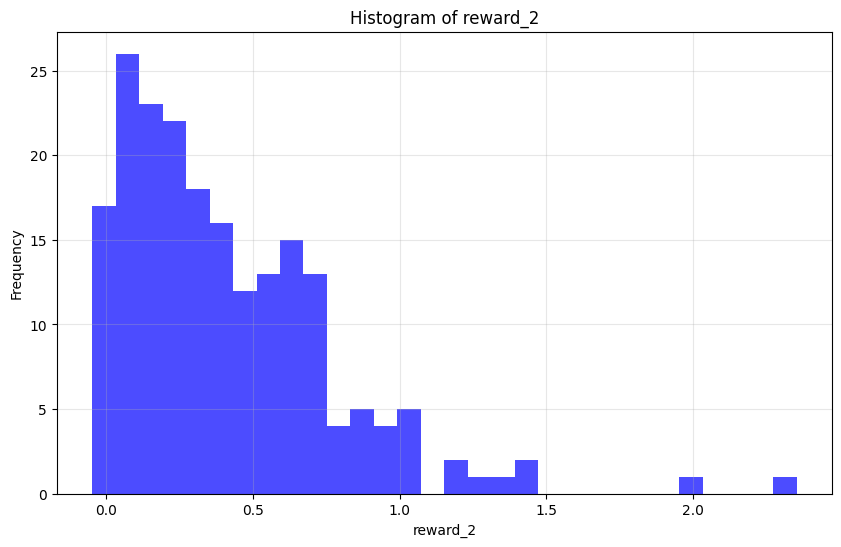

In [75]:
plot_histogram(maddpg_data2, column_name='dos')
plot_histogram(maddpg_data2, column_name='doa')
plot_histogram(maddpg_data2, column_name='reward_0')
plot_histogram(maddpg_data2, column_name='reward_1')
plot_histogram(maddpg_data2, column_name='reward_2')